# Turnover JBS — Aula 3: Análise Exploratória de Dados

A Marina Costa, gerente de RH, mandou dois e-mails. Ela disse que o turnover disparou em 2023 e pediu duas coisas:

1. **Quem é** o colaborador que costuma pedir para sair — um perfil apresentável para a diretoria.
2. Algo que permita **antecipar** quem está propenso a sair.

Hoje atacamos a **pergunta 1**. Não é modelagem, não é feature engineering: é entender o dado a ponto de saber o que dá para prometer para a Marina e o que não dá.

---

## Dicas

1. **Pergunta antes de código.** Se você não consegue dizer em voz alta o que está tentando descobrir, não rode nada ainda.
2. **Aposte antes de rodar.** Onde houver 🎯, escreva sua expectativa **antes** de calcular. Sem isso você vai achar que "já sabia" depois que o resultado aparecer, e não vai aprender nada com o dado.
3. **Achado negativo é achado.** "Testamos X e não explica nada" é resultado legítimo — poupa a empresa de uma política que não funcionaria.

> ⚠️ Há **armadilhas** plantadas neste conjunto de dados: análises que parecem certas, dão números bonitos e levam a conclusões erradas. Quando um resultado parecer bom demais, pergunte: *"que outra coisa poderia produzir esse mesmo número?"*

---
## 0. Setup

Célula pronta — é infraestrutura, não análise. Três detalhes de leitura que valem entender:

- separador é `;` e decimal é `,` (padrão brasileiro);
- `dAnoMes` vem como texto em português (`"ago 2017"`) e já é convertido para `data_competencia`;
- datas completas vêm como `dd/mm/aaaa` e já são convertidas para datas.

Rode e siga.

In [10]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.precision", 6)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4.5),
    "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})

# Resolve a pasta com as bases de forma robusta, mesmo se o notebook rodar
# a partir da pasta do notebook ou da raiz do projeto.
for base in [Path.cwd(), Path.cwd().parent]:
    candidata = base / "Bases de Dados"
    if candidata.exists():
        DATA_DIR = candidata
        break
else:
    DATA_DIR = Path("Bases de Dados")

MESES = {"jan": 1, "fev": 2, "mar": 3, "abr": 4, "mai": 5, "jun": 6,
         "jul": 7, "ago": 8, "set": 9, "out": 10, "nov": 11, "dez": 12}

funcionarios = pd.read_csv(DATA_DIR / "FtFuncionarioRH_amostra.csv", sep=";", decimal=",", low_memory=False)
demitidos = pd.read_csv(DATA_DIR / "FtDemitidosTurnoverRH.csv", sep=";", decimal=",", low_memory=False)
movimento_salarial = pd.read_csv(DATA_DIR / "FtMovimentoSalarialRH.csv", sep=";", decimal=",", low_memory=False)
horas_irregulares = pd.read_csv(DATA_DIR / "FtHorasIrregularesRH.csv", sep=";", decimal=",", low_memory=False)
hora_extra = pd.read_csv(DATA_DIR / "FtHoraExtraRH.csv", sep=";", decimal=",", low_memory=False)
acidentes = pd.read_csv(DATA_DIR / "FtAcidentesRH.csv", sep=";", decimal=",", low_memory=False)
absenteismo = pd.read_csv(DATA_DIR / "FtAbsenteismoMensalRH.csv", sep=";", decimal=",", low_memory=False)
motivos_demitidos = pd.read_csv(DATA_DIR / "MotivosDemitidos_referencia.csv", sep=";", decimal=",", low_memory=False)
# gabarito_desligamentos = pd.read_csv(DATA_DIR / "OLD____GabaritoDesligamentos.csv", sep=";", decimal=",", low_memory=False)

dados = {
    "funcionarios": funcionarios,
    "demitidos": demitidos,
    "movimento_salarial": movimento_salarial,
    "horas_irregulares": horas_irregulares,
    "hora_extra": hora_extra,
    "acidentes": acidentes,
    "absenteismo": absenteismo,
    "motivos_demitidos": motivos_demitidos,
    # "gabarito_desligamentos": gabarito_desligamentos,
}

for df in [funcionarios, demitidos]:
    df["nMes"] = df["cMes"].str.lower().map(MESES)

for df in [funcionarios, demitidos, movimento_salarial, horas_irregulares, hora_extra, acidentes, absenteismo]:
    partes = df["dAnoMes"].astype(str).str.strip().str.split(" ", expand=True)
    df["data_competencia"] = pd.to_datetime({"year": partes[1].astype(int), "month": partes[0].str.lower().map(MESES), "day": 1})

for df in [movimento_salarial, horas_irregulares, hora_extra, acidentes, absenteismo]:
    df["mes_ev"] = df["data_competencia"]

partes = horas_irregulares["dAnoMesRef"].astype(str).str.strip().str.split(" ", expand=True)
horas_irregulares["data_competencia_ref"] = pd.to_datetime({"year": partes[1].astype(int), "month": partes[0].str.lower().map(MESES), "day": 1})

for coluna in ["dDataNascimento", "dDataDemissao", "dDataAdmissao"]:
    demitidos[coluna] = pd.to_datetime(demitidos[coluna], dayfirst=True, errors="coerce")

for coluna in ["dMudanca", "dInclusao", "dReferencia"]:
    movimento_salarial[coluna] = pd.to_datetime(movimento_salarial[coluna], dayfirst=True, errors="coerce")

horas_irregulares["dOcorrencia"] = pd.to_datetime(horas_irregulares["dOcorrencia"], dayfirst=True, errors="coerce")

for coluna in ["dDataHora", "dDataAcidente"]:
    acidentes[coluna] = pd.to_datetime(acidentes[coluna], dayfirst=True, errors="coerce")

# gabarito_desligamentos["dDataDemissao"] = pd.to_datetime(gabarito_desligamentos["dDataDemissao"], dayfirst=True, errors="coerce")

print("Ambiente pronto ? pandas", pd.__version__)
print("Bases carregadas:", ", ".join(dados.keys()))
print("Pasta usada:", DATA_DIR)

Ambiente pronto ? pandas 2.3.3
Bases carregadas: funcionarios, demitidos, movimento_salarial, horas_irregulares, hora_extra, acidentes, absenteismo, motivos_demitidos
Pasta usada: c:\Users\mayumishimizu-ieg\OneDrive - Instituto Germinare\Área de Trabalho\3º ANO\Ciência de Dados II\Turnover\aula1_material_recebido\TurnoverAnalysis\Bases de Dados


---
# PARTE A

---
## A1. Inventário: o que exatamente chegou?

Antes de qualquer gráfico, quatro perguntas sobre **cada** base:

| pergunta | por que importa |
|---|---|
| Quantas linhas e colunas? | dimensiona o trabalho |
| Uma linha representa **o quê**? (a *granularidade*) | define se dá para juntar direto ou se precisa agregar antes |
| A **chave** é única? | se não for, todo `merge` duplica linhas |
| Qual o **período** coberto? | define a janela de análise possível |

In [11]:
IGNORAR = {"motivos_demitidos", "gabarito_desligamentos"}   # não têm nIdPessoa

linhas = []
for nome, df in dados.items():
    if nome in IGNORAR:
        continue
    periodo = (f"{df['data_competencia'].min():%m/%Y} a {df['data_competencia'].max():%m/%Y}"
               if "data_competencia" in df.columns else "—")
    pessoas = df["nIdPessoa"].nunique()
    linhas.append({"base": nome, "linhas": len(df), "colunas": df.shape[1],
                   "pessoas": pessoas,
                   "linhas/pessoa": round(len(df) / pessoas, 1),
                   "período": periodo})

inventario = pd.DataFrame(linhas).sort_values("pessoas", ascending=False).reset_index(drop=True)
display(inventario)

,base,linhas,colunas,pessoas,linhas/pessoa,período
0,funcionarios,24000,29,24000,1.0,01/2016 a 02/2024
1,demitidos,20587,39,19953,1.0,01/2016 a 02/2024
2,movimento_salarial,70448,13,19550,3.6,01/2016 a 02/2024
3,horas_irregulares,296171,27,17746,16.7,01/2016 a 02/2024
4,hora_extra,404786,11,14552,27.8,01/2016 a 02/2024
5,acidentes,3465,39,2806,1.2,01/2016 a 02/2024
6,absenteismo,42376,13,76,557.6,01/2016 a 02/2024


**O que essa tabela já entrega**

- **Duas granularidades.** `funcionarios` e `demitidos` têm ~1 linha por pessoa → **cadastro**. As outras têm N linhas por pessoa → **evento**. Bases de evento **precisam ser agregadas por pessoa** antes de qualquer junção. (É o assunto da próxima aula.)
- **`demitidos` tem 20.587 linhas para 19.953 pessoas.** Não é 1:1 — 634 pessoas têm mais de um vínculo. Guarde isso: vai importar daqui a dois minutos.
- **`absenteismo` tem 42 mil linhas para 76 pessoas.** Cheiro forte de extração parcial (só quem usa o ponto digital `ForPonto`). Reconhecer isso agora economiza horas de trabalho perdido.

---
## A2. O alvo: quem, afinal, "pediu para sair"?

O cadastro tem `cSituacao` com valores "Ativo" e "Demitido". **Parece** o rótulo pronto.

> ❓ **"Demitido" quer dizer que a pessoa pediu para sair?**

Vamos cruzar `cSituacao` com `cIniciativaDemissao` (que veio na base de desligados) e olhar.

**Atenção ao merge:** como `nIdPessoa` não é único em `demitidos`, é preciso escolher **qual** vínculo manter. Aqui ficamos com o **desligamento mais recente** — e isso é uma decisão defendida, não um detalhe técnico.

In [ ]:
ultimo_desligamento = (
    demitidos.sort_values("dDataDemissao")
             .drop_duplicates("nIdPessoa", keep="last")
             [["nIdPessoa", "cIniciativaDemissao", "cDescricaoMotivoDemissao",
               "dDataDemissao", "dDataAdmissao", "nAno"]]
            .rename(columns={"nAno": "ano_desligamento"})
)

base = funcionarios.merge(ultimo_desligamento, on="nIdPessoa", how="left")
base["saiu_voluntario"] = (base["cIniciativaDemissao"] == "Voluntário").astype(int)

print(f"linhas em demitidos ................ {len(demitidos):>7,}")
print(f"pessoas distintas .................. {demitidos['nIdPessoa'].nunique():>7,}")
print(f"pessoas com +1 vínculo ............. {len(demitidos) - demitidos['nIdPessoa'].nunique():>7,}")
print(f"merge 1:1 preservado ............... {len(base) == base['nIdPessoa'].nunique()}")
print(f"alvo saiu_voluntario = 1 ........... {base['saiu_voluntario'].sum():>7,} "
      f"({base['saiu_voluntario'].mean():.1%})")
print()
display(pd.crosstab(base["cSituacao"],
                    base["cIniciativaDemissao"].fillna("(sem registro)"),
                    margins=True, margins_name="Total"))

linhas em demitidos ................  20,587
pessoas distintas ..................  19,953
pessoas com +1 vínculo .............     634
merge 1:1 preservado ............... True
alvo saiu_voluntario = 1 ...........  12,312 (51.3%)



cIniciativaDemissao,(sem registro),Involuntário,Voluntário,Total
cSituacao,,,,
Af.Ac.Trabalho,4,0,0,4
Af.Previdência,134,4,2,140
Apos. por Incapacidade Permanente,75,0,0,75
Ativo,3375,89,333,3797
Aviso Prévio,4,1,0,5
Demitido,2158,5527,11954,19639
Doença Ocupacional,2,0,0,2
Férias,282,5,13,300
Licença Mater.,17,1,6,24


**🪤 A primeira armadilha, e ela é fatal**

Dos **19.639** com situação "Demitido": **11.954 pediram para sair** e **5.527 foram desligados pela empresa**. São fenômenos de negócio **opostos**.

Reter os primeiros é o problema da Marina. Os segundos, na maioria dos casos, a empresa **quis** desligar. Um modelo treinado com alvo `cSituacao == "Demitido"` aprende a prever baixa produtividade e faltas — e responde a pergunta errada.

Repare também nos **2.158** "Demitido" sem registro na base de desligados (as duas extrações vêm de recortes diferentes) e nos **422 "Ativo"** que aparecem como desligados — a "inconsistência" que a Marina avisou. Voltaremos nela.

👉 **Alvo definido:** `saiu_voluntario = 1` quando `cIniciativaDemissao == "Voluntário"`. `cSituacao` é variável de contexto, não rótulo.

---
## A3. Que amostra é essa, afinal?

51,3% da amostra pediu demissão.

> ❓ **Então o turnover voluntário da JBS é 51%?**

Antes de responder, olhe **como a amostra foi montada** — a composição ano a ano denuncia tudo.

In [13]:
comp = pd.crosstab(base["nAno"], base["cSituacao"])
tabela = pd.DataFrame({"Ativo": comp.get("Ativo", 0), "Demitido": comp.get("Demitido", 0)})
tabela["outras situações"] = comp.sum(axis=1) - tabela.sum(axis=1)
display(tabela)

,Ativo,Demitido,outras situações
nAno,,,
2016,58,2127,11
2017,48,1842,0
2018,58,1870,3
2019,45,1909,2
2020,44,2179,5
2021,74,2991,6
2022,69,2925,4
2023,152,3345,7
2024,3249,451,526


**Não.** A amostra é um **empilhamento de desligamentos históricos (2016–2023) + uma foto do quadro atual (fev/2024)**. Nos anos passados só entrou quem saiu; em 2024 entrou quem está ativo.

Logo, os 51,3% não são taxa de turnover — são só a proporção de saídas voluntárias *dentro dessa construção*.

👉 **Regra do projeto:** só fazemos **comparação relativa** ("o turno 2 sai mais que o turno 1"). Nunca "a taxa é X%". Para taxa absoluta seria preciso pedir à Marina o **headcount mensal por unidade** — item para a lista de pedidos no fim da aula.

Daqui para frente, **"taxa amostral de saída voluntária"** = métrica relativa, boa para comparar grupos, inválida como número absoluto.

---
## A4. A ferramenta — e um exemplo resolvido

Você vai calcular a mesma taxa umas dez vezes na Parte B. Esta função faz isso.

Dois parâmetros importam:

- **`minimo`**: uma categoria com n = 3 pode dar 100% e não significar nada. Filtrar grupos pequenos evita apresentar ruído como achado.
- **`ordem`**: para variáveis com ordem natural (faixas de tempo de casa, faixas etárias), ordenar por taxa destrói a leitura — você quer ver se existe **gradiente**.

O exemplo abaixo já responde uma pergunta de verdade: **tempo de casa**.

,taxa,n
cFaixasTempoDeCasa,,
Até 3 Meses,59.4,5703
De 3 a 6 Meses,72.2,2805
De 6 Meses a 1 Ano,62.0,4028
De 1 a 2 Anos,53.5,4122
De 2 a 5 Anos,38.2,4283
De 5 a 10 Anos,23.2,1811
Acima de 10 Anos,11.2,1248


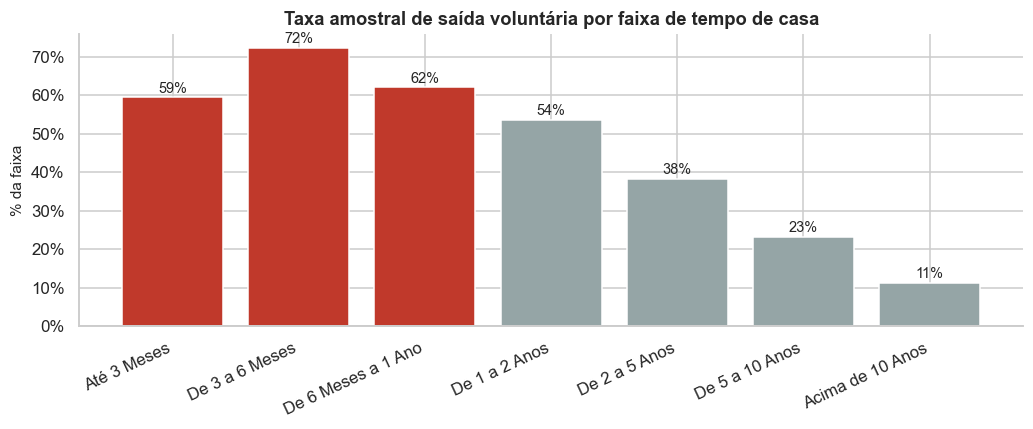

In [14]:
ORDEM_TC = ["Até 3 Meses", "De 3 a 6 Meses", "De 6 Meses a 1 Ano", "De 1 a 2 Anos",
            "De 2 a 5 Anos", "De 5 a 10 Anos", "Acima de 10 Anos"]
ORDEM_IDADE = ["Até 18", "De 19 a 25", "De 26 a 30", "De 31 a 35", "De 36 a 45", "Acima de 45"]

def taxa_por(col, minimo=50, ordem=None, df=None):
    """Taxa amostral de saída voluntária (%) por categoria, com n mínimo."""
    d = base if df is None else df
    g = d.groupby(col, dropna=False)["saiu_voluntario"].agg(taxa="mean", n="size")
    g = g[g["n"] >= minimo]
    g["taxa"] = (g["taxa"] * 100).round(1)
    return g.reindex(ordem).dropna(subset=["taxa"]) if ordem else g.sort_values("taxa", ascending=False)


tc = taxa_por("cFaixasTempoDeCasa", ordem=ORDEM_TC)
display(tc)

fig, ax = plt.subplots(figsize=(9.5, 4))
ax.bar(range(len(tc)), tc["taxa"],
       color=["#c0392b" if v > 55 else "#95a5a6" for v in tc["taxa"]])
ax.set_xticks(range(len(tc))); ax.set_xticklabels(tc.index, rotation=25, ha="right")
ax.set_title("Taxa amostral de saída voluntária por faixa de tempo de casa")
ax.set_ylabel("% da faixa"); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(tc["taxa"]):
    ax.text(i, v + 1.2, f"{v:.0f}%", ha="center", fontsize=9.5)
plt.tight_layout(); plt.show()

,n_saiu,n,taxa
cFaixasTempoDeCasa,,,
Até 3 Meses,3386,5703,59.4
De 3 a 6 Meses,2025,2805,72.2
De 6 Meses a 1 Ano,2498,4028,62.0
De 1 a 2 Anos,2207,4122,53.5
De 2 a 5 Anos,1636,4283,38.2
De 5 a 10 Anos,420,1811,23.2
Acima de 10 Anos,140,1248,11.2


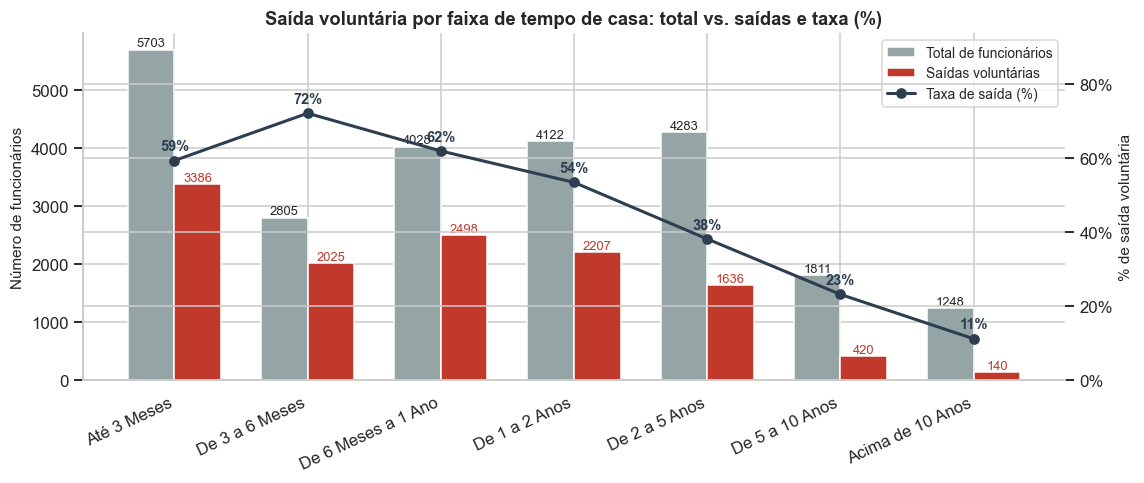

In [15]:
ORDEM_TC = ["Até 3 Meses", "De 3 a 6 Meses", "De 6 Meses a 1 Ano", "De 1 a 2 Anos",
            "De 2 a 5 Anos", "De 5 a 10 Anos", "Acima de 10 Anos"]
ORDEM_IDADE = ["Até 18", "De 19 a 25", "De 26 a 30", "De 31 a 35", "De 36 a 45", "Acima de 45"]

def taxa_por(col, minimo=50, ordem=None, df=None):
    """Taxa amostral de saída voluntária (%) por categoria, com n mínimo.
    Agora também retorna n (total) e n_saiu (saídas voluntárias) em valores absolutos."""
    d = base if df is None else df
    g = d.groupby(col, dropna=False)["saiu_voluntario"].agg(n_saiu="sum", n="size")
    g = g[g["n"] >= minimo]
    g["taxa"] = (g["n_saiu"] / g["n"] * 100).round(1)
    return g.reindex(ordem).dropna(subset=["taxa"]) if ordem else g.sort_values("taxa", ascending=False)


tc = taxa_por("cFaixasTempoDeCasa", ordem=ORDEM_TC)
display(tc)

x = np.arange(len(tc))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10.5, 4.5))

bars_total = ax1.bar(x - width/2, tc["n"], width, label="Total de funcionários", color="#95a5a6")
bars_saida = ax1.bar(x + width/2, tc["n_saiu"], width, label="Saídas voluntárias", color="#c0392b")

ax1.set_xticks(x)
ax1.set_xticklabels(tc.index, rotation=25, ha="right")
ax1.set_ylabel("Número de funcionários")
ax1.set_title("Saída voluntária por faixa de tempo de casa: total vs. saídas e taxa (%)")

# rótulos nas barras
for b in bars_total:
    h = b.get_height()
    ax1.text(b.get_x() + b.get_width()/2, h + tc["n"].max()*0.01, f"{int(h)}",
              ha="center", fontsize=8.5)
for b in bars_saida:
    h = b.get_height()
    ax1.text(b.get_x() + b.get_width()/2, h + tc["n"].max()*0.01, f"{int(h)}",
              ha="center", fontsize=8.5, color="#c0392b")

# linha com a taxa % no eixo secundário
ax2 = ax1.twinx()
ax2.plot(x, tc["taxa"], color="#2c3e50", marker="o", linewidth=2, label="Taxa de saída (%)")
ax2.set_ylabel("% de saída voluntária")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.set_ylim(0, max(tc["taxa"].max() * 1.3, 10))

for xi, v in zip(x, tc["taxa"]):
    ax2.text(xi, v + ax2.get_ylim()[1]*0.03, f"{v:.0f}%",
              ha="center", fontsize=9.5, color="#2c3e50", fontweight="bold")

# legenda combinada (barras + linha)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

**O primeiro achado grande da aula**

A faixa **"De 3 a 6 Meses" tem 72,2%** — quase três em cada quatro saídas dessa faixa são a pedido do colaborador. **"Acima de 10 Anos" tem 11,2%.** Uma diferença de **6,4x**.

O turnover voluntário aqui **não é um problema de carreira, é um problema de entrada**.

⚠️ **Ressalva metodológica:** faixas curtas concentram mais gente porque *todo mundo passa por elas* — a comparação bruta mistura risco com exposição. Na Parte B você vai comparar voluntário × involuntário **dentro** da mesma faixa, onde a exposição é a mesma para os dois grupos.

---

> **É isso. A partir daqui é com vocês.**

---
# PARTE B — Sua vez

| bloco | assunto 
|---|---|
| **B1** | Qualidade: cace o que vai estragar a análise |
| **B2** | A premissa da Marina: o turnover disparou em 2023? | 
| **B3** | O perfil de quem pede para sair | 
| **B4** | A armadilha | 

Você já tem `base`, `saiu_voluntario`, `taxa_por()`, `ORDEM_TC` e `ORDEM_IDADE`.

## B1. Qualidade: cace o que vai estragar a análise

A Marina avisou: *"não foram feitas pensando em análise, então provavelmente vêm meio cruas"*. O estrago de dado cru só aparece três semanas depois, quando o modelo está pronto e ninguém entende o resultado.

> **Missão: encontre pelo menos 6 problemas.** Não vou dizer quais são — vou dizer **onde procurar**.

**(a) Nulos, com a pergunta certa.** Calcule o % de nulos por coluna em `funcionarios` e `demitidos`. Para cada coluna com muito nulo, responda:

> **O nulo aqui significa "não sei" ou significa "não aconteceu"?**

Não é filosofia, muda o tratamento. Se `nNrDependentes` é nulo porque a pessoa não tem dependentes, o preenchimento certo é `0`. Se é nulo porque ninguém preencheu, colocar `0` é **inventar dado**. Decida para `nNrDependentes` e para `cTurno`.

**(b) Valores que não podem existir.** Vasculhe as colunas numéricas:

- tem algo **negativo** onde não pode? (olhe `nTempoDeCasaAnos`)
- tem **máximo absurdo**? (`nIdade` em `funcionarios`; `nMinutosTrabalhados` em `horas_irregulares` — converta para dias antes de julgar)
- tem **zero** onde zero não faz sentido? (`nSalarioTotal`)
- alguma coluna é **constante**? Uma coluna com um único valor distinto não carrega informação. (teste `.nunique()` nas colunas de minutos)
- alguma coluna está **quase toda vazia**? (`nDiasDebito` em `acidentes`: preenchidas / total)

> 💡 Ao achar cada anomalia, classifique: é **erro de cadastro** (alguém digitou errado) ou **artefato explicável** (efeito da data de corte da extração)? Os dois vão para o relatório, com tratamentos diferentes.

**(c) Categorias que deveriam ser a mesma.** Este é o mais traiçoeiro: não aparece em `.describe()` nem em contagem de nulos. Só aparece se você **olhar os valores um a um**.

- Liste os valores distintos de `cCargo` em `demitidos`. São 8. **Leia os 8**, não só conte — dois são a mesma coisa. (dica: imprima com `repr()`, ex. `print(f"{v!r}")`, para ver os caracteres como estão)
- Conte as categorias de `cDescricaoMotivoDemissao`. Depois filtre as que contenham "famil", "adapta" ou "falta" e leia a lista. Quantos **conceitos de negócio diferentes** existem ali de verdade?

### ❓ Responda
1. Liste os problemas: onde está, quantas linhas afeta, erro ou artefato, tratamento proposto.
2. Qual deles causaria o **maior estrago** se passasse batido?
3. Por que categorias quase-duplicadas acontecem em sistemas de RH? (troca de sistema, digitação livre, mudança de política)

In [ ]:
# A)

In [ ]:
# B) 


In [ ]:
# C)

### 📝 Registre

| problema | onde | linhas afetadas | erro ou artefato? | tratamento |
|---|---|---|---|---|
| | | | | |
| | | | | |
| | | | | |
| | | | | |
| | | | | |
| | | | | |

---
## B2. A premissa da Marina: o turnover disparou em 2023?

A diretoria inteira está trabalhando com essa premissa.

> **Como cientista de dados, você valida tudo pelo dado — inclusive (principalmente) a premissa de quem pediu o trabalho.** Se a premissa estiver torta, todo o plano de ação construído em cima dela está torto junto.

E repare que a frase dela tem **duas partes**, que se testam separadamente:

- o **efeito** — o turnover subiu?
- a **causa implícita** — subiu porque as pessoas estão saindo mais, ou porque a empresa está demitindo mais?

### B2.1 A série anual

Construa um **gráfico de linhas** com desligamentos por ano, **uma linha para cada `cIniciativaDemissao`**. Use `demitidos` e a data real (`dDataDemissao`), não a competência.

**Dicas**
- `demitidos["dDataDemissao"].dt.year` já funciona (a data foi convertida no setup).
- **Corte 2024:** a série termina em fevereiro. Incluir o ano incompleto faz parecer que o turnover despencou — erro de leitura clássico. Corte ou sinalize.
- `groupby([ano, iniciativa]).size().unstack()` deixa no formato de `.plot()`.
- Acrescente uma segunda visão: a **participação percentual** do voluntário no total, ano a ano. Às vezes o percentual conta o que o absoluto esconde.

### ❓ Responda
1. As duas linhas se comportam igual? Descreva cada uma em uma frase.
2. **A premissa está certa?** Separe: o efeito está certo? A causa implícita está certa?
3. Na linha voluntária, o salto é mesmo em 2023, ou o ano de virada é outro?
4. De quanto foi o crescimento do voluntário entre o primeiro e o último ano completo? E do involuntário?
5. Se o involuntário não subiu, **qual área da empresa é dona do problema**?

In [18]:
# ✏️ seu código aqui


### B2.2 O zoom mensal

A série anual mostra que algo mudou, mas não **quando** dentro do ano. Um **heatmap** de ano × mês deixa ler 96 meses de uma vez.

Monte um heatmap com **anos nas linhas, meses nas colunas e o nº de saídas voluntárias nas células**.

**Dicas**
- `sns.heatmap(matriz, cmap="Reds", annot=True, fmt=".0f")` — com `annot=True` você lê valor e cor ao mesmo tempo, o que ajuda muito na hora de apresentar.
- A matriz sai de um `groupby([ano, mês]).size().unstack()`.
- Troque os rótulos numéricos dos meses por nomes — detalhe pequeno, diferença grande na leitura.

### ❓ Responda
1. Percorra o heatmap **linha por linha**. Em que ponto exato o padrão de cor muda de patamar? Aponte mês e ano.
2. Existe uma região **anormalmente clara** em 2020? Em quais meses? **Que evento do mundo real** explica — e o que aconteceu logo depois?
3. Depois da mudança de patamar, a série volta ao nível anterior?
4. **Existe sazonalidade mensal?** Some as saídas voluntárias por mês juntando todos os anos e compare os 12 números. ("sai mais depois do 13º", "sai mais em janeiro" — teste.)
5. Se **não** houver sazonalidade, isso é resultado inútil ou útil? O que ele te poupa de fazer na próxima aula?

In [19]:
# ✏️ seu código aqui


### 📝 Registre

- A premissa da Marina, corrigida, em uma frase: ...
- Ano/mês da verdadeira virada: ...
- Comportamento da linha involuntária: ...
- Existe sazonalidade? Evidência: ...
- **Manchete do slide 1:** ...

---
## B3. O perfil: quem é a pessoa que pede para sair?

esta é a **pergunta 1 da Marina**, a que vira slide para a diretoria.

Você já viu na Parte A que tempo de casa é o eixo mais forte. Agora percorra o resto.

### B3.1 Rodada de variáveis

Use `taxa_por()` em: `cFaixasIdade` (com `ORDEM_IDADE`), `cGeracaoNascimento`, `cSexo`, `cEscolaridade`, `cEstadoCivil`, `cTurno`, `cCargo`, `cEstadoEndereco` e `EMPRESA`. Ajuste o `minimo` por variável (para `EMPRESA` use algo como 150; para estados, 180).

Faça pelo menos um gráfico de barras — o do `cEstadoEndereco` costuma ser o mais impressionante.

### ❓ Responda
1. Ordene as variáveis pela **capacidade de separar** (diferença entre o maior e o menor grupo). Quais valem levar à diretoria e quais são ruído?
2. Em idade: existe gradiente? Alguma faixa quebra o padrão — e por quê? (olhe o `n` e o tipo de contrato dessas pessoas)
3. **A pergunta que importa:** taxa maior entre os jovens é efeito de **idade** ou de **tempo de casa**? Quem tem 22 anos quase por definição tem pouco tempo de casa. Como você separaria as duas coisas?
4. `cTurno` tem ~33% de nulos e o grupo nulo tem taxa própria bem diferente. Esse nulo é "não sei" ou "não se aplica"? Quem são essas pessoas? Vira categoria ou sai?
5. **Distinção que vale ouro na apresentação:** entre as variáveis que separam bem, quais são **acionáveis** (a empresa pode mexer) e quais são só **descritivas** (ninguém muda a idade de ninguém)? Faça as duas listas — qual interessa ao gestor de área?
6. O padrão por estado é aleatório ou tem geografia? Que característica do **mercado de trabalho local** poderia explicar? (onde há muitos frigoríficos concorrendo, sair é fácil ou difícil?)

In [20]:
# ✏️ seu código aqui


In [21]:
# ✏️ seu código aqui


### B3.2 Salário

### 🎯 Aposte primeiro

> **"Quem sai é quem ganha menos."** É a hipótese que praticamente todo RH dá como certa.

Escreva: que diferença você espera entre o salário de quem pede demissão e o de quem é desligado?

**O que fazer**
1. Compare `nSalarioTotal` entre Voluntário e Involuntário em `demitidos` — descritivas **e** boxplot. (tire os salários zerados que você achou em B1; limite o eixo para os outliers não achatarem as caixas)
2. Agora olhe outra coisa: `taxa_por("cPosicaoFaixaSalarial")` — que mede **onde a pessoa está dentro da faixa do próprio cargo**, não quanto ela ganha.

### ❓ Responda
1. A hipótese se sustenta? Quanto separa as medianas?
2. Se salário absoluto não separa, **por quê?** Olhe a composição de `cCargo` antes de responder. (variável que quase não varia dentro da população não explica variação de comportamento)
3. Posição na faixa separa? É **gradiente suave** ou **degrau** em alguma posição? Descreva a forma, não só a direção.
4. ⚠️ Antes de concluir que "posição na faixa causa saída": que outra variável está fortemente correlacionada com ela? (quem entrou ontem está onde na faixa?)
5. **Como apresentar um achado negativo à diretoria** sem parecer que não achou nada? Escreva a frase que você usaria.

In [22]:
# ✏️ seu código aqui


### 📝 Registre — o retrato

Monte o perfil-síntese dentro de `saiu_voluntario == 1` (medianas e categorias mais frequentes):

| característica | valor |
|---|---|
| Idade mediana | |
| Tempo de casa mediano | |
| Salário mediano | |
| Cargo mais frequente | |
| Sexo / escolaridade / estado civil | |
| Posição na faixa mais frequente | |
| % que saiu em até 6 meses | |

**Separam bem:** ... · **Não separam (achados negativos):** ... · **Acionáveis:** ...

---
## B4. A armadilha

a análise mais bonita da aula. **Siga os três passos NA ORDEM e não pule para o fim.**

**Passo 1.** Olhe `cMotivo` em `movimento_salarial`. A maioria é reajuste **coletivo**, que atinge todo mundo e não diz nada sobre a pessoa. Isole só o **reconhecimento individual**: `Mérito` e `Promoção`.

Crie a binária *"esta pessoa já recebeu mérito ou promoção"* e calcule a taxa amostral para quem tem e quem não tem.

> **Anote o resultado agora**, com o número, antes de continuar. **Escreva também a manchete que você colocaria no slide.**

**Passo 2.** Faça **exatamente a mesma comparação**, agora separada por `cFaixasTempoDeCasa`. Uma linha por faixa, duas colunas (com e sem mérito), o `n` de cada célula, e a diferença em pontos percentuais.

**Passo 3.** Se o Passo 2 te surpreendeu, ache o mecanismo: distribuição de `cFaixasTempoDeCasa` **dentro** de quem teve mérito e **dentro** de quem não teve (`pd.crosstab(..., normalize="columns")`).

**Dicas**
- `com_merito = set(movimento_salarial.loc[movimento_salarial["cMotivo"].isin(["Mérito","Promoção"]), "nIdPessoa"])`
- `base.pivot_table(index=..., columns=..., values="saiu_voluntario", aggfunc="mean")`

### ❓ Responda
1. Qual era a manchete do Passo 1? De quantos pontos percentuais era a diferença?
2. O que sobrou dela no Passo 2? Em quantas faixas a diferença sumiu? Em alguma o **sinal se inverteu**?
3. O Passo 3 explica o truque. Descreva o mecanismo em uma frase, no formato: *"A é dado principalmente a quem tem B, e B é o que realmente determina C."*
4. Esse fenômeno tem nome. Pesquise **paradoxo de Simpson** e escreva a definição com suas palavras.
5. **O custo real do erro:** se a análise tivesse parado no Passo 1, que política de RH seria recomendada? Ela funcionaria?
6. **A regra geral:** que variável apareceu como confundidor em B3.1, B3.2 e agora aqui? Escreva a regra que você vai seguir pelo resto do projeto.

In [23]:
# ✏️ seu código aqui


In [24]:
# ✏️ seu código aqui


### 📝 Registre

- Manchete falsa do Passo 1, e o que restou dela: ...
- Mecanismo em uma frase: ...
- **A regra sobre o confundidor-mestre:** ...

---
# PARTE C — Extras


## C1. As bases auxiliares valem o esforço?

Cinco bases de evento chegaram. Nem todas servem.

**C1.1 Cobertura.** Para cada base auxiliar, calcule: quantas pessoas distintas contém, quantas estão no seu cadastro, e que % do cadastro isso representa.

- Onde está o corte entre "usável" e "inviável"?
- **Distinção crucial, e responda base por base:** quando alguém **não aparece** numa base auxiliar, o evento **não aconteceu** ou **não foi capturado**? Compare *acidentes* com *absenteísmo* — em qual dos dois "ausência = zero" é defensável?

**C1.2 O viés escondido.** Crie a binária *"aparece na base de hora extra (sim/não)"* e compare a proporção entre quatro grupos: saiu voluntário, saiu involuntário, ativo, sem registro de saída. **Vai parecer uma variável excelente.**

Antes de comemorar: calcule o **tempo de casa mediano** de cada grupo e ponha lado a lado.

- Então "aparece na base" mede **comportamento** ou **tempo de exposição**?
- Ela seria útil aplicada a alguém que entrou mês passado?
- **Generalize:** escreva a regra sobre `count` cru em bases de evento.

In [25]:
# ✏️ seu código aqui


---
## C2. Hora extra: teste a hipótese do burnout

### 🎯 Aposte primeiro

> **"Quem faz muita hora extra se esgota e pede as contas."**

Qual o sinal esperado da relação? Escreva antes de rodar.

**Ferramenta.** Você aprendeu em C1 que precisa de **janela fixa**. Esta função faz isso (as bases de evento já têm `mes_ev`, criada no setup):

```python
base["mes_ref"] = base["data_competencia"]

def janela(ev, col_valor, lag_min=1, lag_max=3, agg="sum"):
    x = ev.merge(base[["nIdPessoa", "mes_ref"]], on="nIdPessoa")
    x["lag"] = ((x["mes_ref"].dt.year - x["mes_ev"].dt.year) * 12
                + (x["mes_ref"].dt.month - x["mes_ev"].dt.month))
    x = x[x["lag"].between(lag_min, lag_max)]
    return (x.groupby("nIdPessoa")[col_valor].agg(agg) if col_valor
            else x.groupby("nIdPessoa").size())
```

> ❓ Por que `lag_min=1` e não `0`? O que o mês da própria saída tem de problemático?

**O que fazer**
1. Filtre `hora_extra` para o que é de fato hora extra (olhe `cDescricao`).
2. Some `nReferencia` na janela de 1 a 3 meses e divida por 3 → média mensal.
3. Faixas (`0h`, `0–5h`, `5–15h`, `15–30h`, `30h+`) e taxa em cada.
4. **Cruze com `cFaixasTempoDeCasa`** — mostre taxa **e** `n` por célula.

### ❓ Responda
1. Qual o sinal? Sua aposta estava certa?
2. O efeito **sobrevive** ao controle por tempo de casa, ou some?
3. Olhe a faixa `0h`. Ela é a mais alta, como o gradiente sugeriria? **Se não, por quê?** Volte a C1: que % do cadastro aparece na base de hora extra? O que está **misturado** dentro do grupo "0h"?
4. **A parte difícil, sem resposta única:** proponha **três** explicações plausíveis e defenda uma. Pistas: o que hora extra representa no contracheque de quem está no piso? Ela é distribuída aleatoriamente ou oferecida a alguns? E se a causalidade for invertida — o que faz alguém que **já decidiu sair**?
5. Como testar a terceira explicação? (dica: `lag_min=4, lag_max=6`)
6. Dependendo de qual explicação for a certa, a recomendação de negócio é **oposta**. Escreva as duas.

In [26]:
# ✏️ seu código aqui


---
## C3. Os motivos declarados

> ❓ **Por que `cDescricaoMotivoDemissao` NÃO pode ser variável preditiva?** Em que momento essa informação passa a existir? O modelo terá esse campo no momento da previsão?
>
> O nome técnico é **vazamento de dado (*data leakage*)**. Um modelo que vê "Outra proposta de emprego" acerta ~100% e é inútil. **Acurácia alta demais é motivo de desconfiança, não de comemoração.**

O motivo não serve para prever, mas serve para **dar sentido** aos padrões.

1. Liste os 10 motivos mais frequentes entre voluntários e entre involuntários, lado a lado.
2. Compare a distribuição percentual dos principais motivos entre sua amostra de voluntários e `motivos_demitidos` (a base de referência, 156 mil registros de uma população maior). Normalize pelo **total de voluntários**, não pela soma dos 10 primeiros.

> ⚠️ `motivos_demitidos` **não tem `nIdPessoa`** e **não deve ser mesclada** com nada — juntar por posição de linha inventaria associações falsas.

### ❓ Responda
1. Some "Outra proposta de emprego" + "Melhor proposta externa". Que fração das saídas voluntárias é **atração externa** (mercado puxando) e não repulsa interna? Como isso conversa com o achado geográfico de B3.1?
2. Some "Insatisfação com salário" + "Insatisfação com o Gestor". Que fração dá? **Como isso se relaciona com B3.2?** Escreva o argumento combinado — duas evidências de naturezas diferentes na mesma direção valem mais que uma.
3. O motivo mais frequente é bem genérico. Que fração representa? **Você acredita nele?** Pense em quem preenche o campo e em quem sai dizendo "meu gestor é insuportável".
4. A distribuição bate com a base de referência? O que isso permite afirmar sobre a **representatividade** da amostra?

In [27]:
# ✏️ seu código aqui


---
## C4. Exercícios

**1. Idade ou tempo de casa?** B3.1 mostrou taxa maior entre os jovens. Refaça controlando por faixa de tempo de casa, com a técnica de B4. O efeito de idade sobrevive? Quanto dele era tempo de casa disfarçado? **Escreva a conclusão nos dois cenários possíveis antes de calcular.**

**2. Causalidade invertida da hora extra.** Refaça C2 com `lag_min=4, lag_max=6`. Se o efeito enfraquecer na janela distante, qual explicação ganha força? Se não mudar, qual perde? **Escreva a previsão antes de rodar.**

**3. Consolidação de motivos.** As 67 categorias viram quantos **temas** de negócio? Proponha um agrupamento (*Atração externa*, *Vida pessoal/familiar*, *Condições de trabalho*, *Relação com gestão*, *Saúde*, *Outros*), implemente e reveja a distribuição. A história de C3 muda?

**4. Efeito de unidade, de verdade.** Pegue a unidade com maior e a com menor taxa em B3.1. Quanto da diferença é **gestão** e quanto é **composição** (mix de cargo, turno, idade, tempo de casa)? Compare dentro da mesma faixa de tempo de casa e mesmo cargo. Quanto sobra?

**5. O grupo mais interessante do RH.** Aquelas 422 pessoas "Ativas" que aparecem como desligadas: elas saíram e **voltaram**. Se a pessoa volta, o motivo declarado da saída era mesmo insatisfação? Isole o grupo, veja os motivos e compare com a distribuição geral. Que hipótese sobre a qualidade de `cDescricaoMotivoDemissao` isso sugere?

**6. 🔥 O desafio.** Encontre uma armadilha **não coberta** neste caderno — uma análise que parece certa, dá número convincente e leva a conclusão errada. Dois slides: a versão errada (bem convincente) e a correção.

> *Pista: rode `funcionarios["cSecao"].nunique()`. Depois pense no que acontece com uma taxa calculada sobre um grupo de 3 pessoas — e no que acontece quando você ordena milhares desses grupos e apresenta o "top 10".*

---
## 🏁 Fechamento — o que a Marina recebe

**Dois slides. A plateia é a diretoria, não a banca.** Sem jargão, sem "fizemos um crosstab", sem tabela de 40 linhas.

**Slide 1 — O diagnóstico.** Uma frase que reposiciona o problema, e um gráfico só. Você validou a premissa da Marina em B2 — **corrigir a premissa do cliente é a entrega mais valiosa que você tem**, desde que venha com evidência e sem soberba.

**Slide 2 — O perfil de risco.** Ordenado por **poder de separação**, não por ordem de cálculo. Inclua ao menos um **achado negativo** e diga por que ele importa.


### Uma última coisa

Se você sair desta aula com **uma** frase: **quando um resultado parecer bom demais, procure a variável que está se escondendo atrás dele.**

Neste conjunto de dados, três armadilhas diferentes eram **a mesma variável** (tempo de casa) usando disfarces diferentes.